# Artisan

In [7]:
from artisan.operations.curator import Filter, IngestData, Merge
from artisan.operations.examples import (
    DataGenerator,
    DataTransformer,
    MetricCalculator,
)
from artisan.orchestration import PipelineManager
from artisan.utils import find_project_root, tutorial_setup
from artisan.visualization import (
    build_macro_graph,
    build_micro_graph,
    inspect_metrics,
    inspect_pipeline,
)

PROJECT_ROOT = find_project_root()
SOURCE_FILES = sorted((PROJECT_ROOT / "tests" / "fixtures" / "csv").glob("*.csv"))[:2]

env = tutorial_setup("demo")
DELTA_ROOT = env.delta_root

pipeline = PipelineManager.create(
    name="demo",
    delta_root=env.delta_root,
    staging_root=env.staging_root,
    working_root=env.working_root,
)
output = pipeline.output

13:45:08.112 | INFO    | artisan.orchestration.prefect_server - Prefect self-hosted: http://127.0.0.1:4701/api (source: env:PREFECT_API_URL)

13:45:08.114 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'demo' initialized (run_id=demo_20260402_204508_89775868)

13:45:08.114 | INFO    | artisan.orchestration.pipeline_manager -   delta_root: /Users/ach/git/artisan/dev/_dev/demos/presentation/runs/demo/delta

13:45:08.115 | INFO    | artisan.orchestration.pipeline_manager -   staging_root: /Users/ach/git/artisan/dev/_dev/demos/presentation/runs/demo/staging

## Build a pipeline

In [8]:
# Two data sources: external files and synthetic generation
pipeline.run(operation=IngestData, name="ingest", inputs=[str(f) for f in SOURCE_FILES])
pipeline.run(operation=DataGenerator, name="generate", params={"count": 2, "seed": 44})

# Merge into a single stream — output() wires steps together by name and role
pipeline.run(
    operation=Merge,
    name="merge",
    inputs={
        "branch_a": output("ingest", "data"),
        "branch_b": output("generate", "datasets"),
    },
)

13:45:09.559 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (ingest) starting... [backend=local]

13:45:09.794 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (ingest) completed in 0.2s [2/2 succeeded]

13:45:09.800 | INFO    | artisan.orchestration.pipeline_manager - Step 1 (generate) starting... [backend=local]

13:45:10.607 | INFO    | artisan.orchestration.engine.dispatch - Collected results from 1 futures

13:45:10.756 | INFO    | artisan.orchestration.pipeline_manager - Step 1 (generate) completed in 1.0s [1/1 succeeded]

13:45:10.762 | INFO    | artisan.orchestration.pipeline_manager - Step 2 (merge) starting... [backend=local]

13:45:10.967 | INFO    | artisan.orchestration.pipeline_manager - Step 2 (merge) completed in 0.2s [4/4 succeeded]

StepResult(step_name='merge', step_number=2, success=True, total_count=4, succeeded_count=4, failed_count=0, output_roles=frozenset({'merged'}), output_types={'merged': 'any'}, duration_seconds=0.20110970799578354, metadata={'timings': {'resolve_inputs': 0.0054, 'batch_and_cache': 0.0, 'execute': 0.177, 'verify_staging': 0.0, 'commit': 0.0092, 'compact': 0.0093, 'total': 0.201}})

In [9]:
# Transform, score, and filter
pipeline.run(
    operation=DataTransformer,
    name="transform",
    inputs={"dataset": output("merge", "merged")},
    params={"scale_factor": 0.5, "variants": 1, "seed": 100},
)
pipeline.run(
    operation=MetricCalculator,
    name="metrics",
    inputs={"dataset": output("transform", "dataset")},
)

# Filter auto-discovers metrics via provenance — no explicit link needed
pipeline.run(
    operation=Filter,
    name="filter",
    inputs={"passthrough": output("transform", "dataset")},
    params={
        "criteria": [{"metric": "distribution.median", "operator": "gt", "value": 0.15}]
    },
)

_ = pipeline.finalize()

13:45:11.679 | INFO    | artisan.orchestration.pipeline_manager - Step 3 (transform) starting... [backend=local]

13:45:12.636 | INFO    | artisan.orchestration.engine.dispatch - Collected results from 4 futures

13:45:12.873 | INFO    | artisan.orchestration.pipeline_manager - Step 3 (transform) completed in 1.2s [4/4 succeeded]

13:45:12.881 | INFO    | artisan.orchestration.pipeline_manager - Step 4 (metrics) starting... [backend=local]

13:45:13.701 | INFO    | artisan.orchestration.engine.dispatch - Collected results from 1 futures

...

13:45:14.104 | INFO    | artisan.orchestration.pipeline_manager -   Step 2: merge            0.2s  [4/4]

13:45:14.104 | INFO    | artisan.orchestration.pipeline_manager -   Step 3: transform        1.2s  [4/4]

13:45:14.105 | INFO    | artisan.orchestration.pipeline_manager -   Step 4: metrics          1.0s  [4/4]

13:45:14.105 | INFO    | artisan.orchestration.pipeline_manager -   Step 5: filter           0.2s  [3/3]

13:45:14.105 | INFO    | artisan.orchestration.pipeline_manager -   Total: 6.0s

## Inspect results

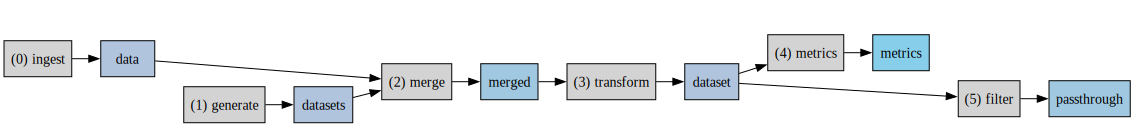

In [10]:
build_macro_graph(DELTA_ROOT)

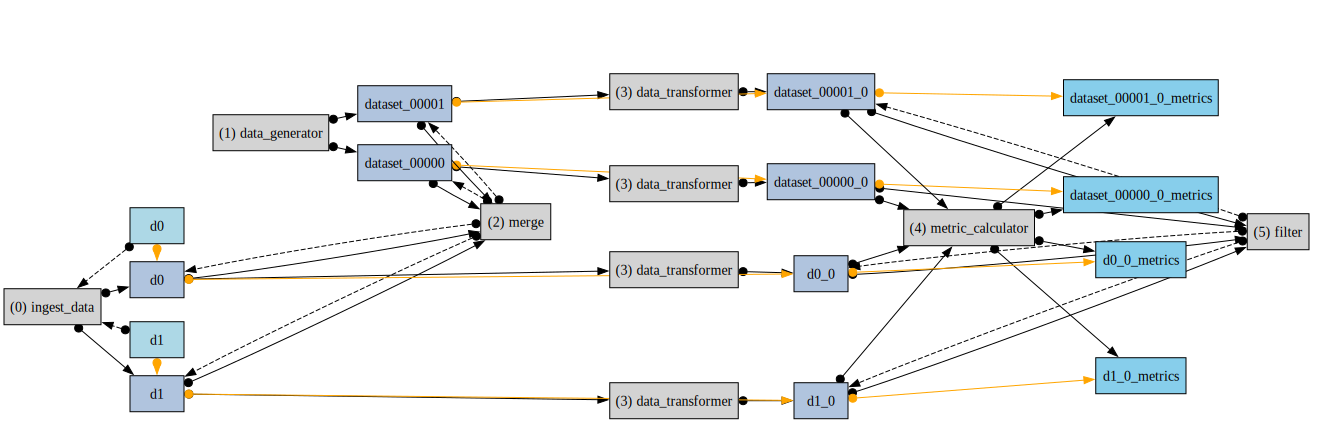

In [11]:
build_micro_graph(DELTA_ROOT)